In [ ]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
!wget https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/datasets/MNIST_Data.zip
# !wget -O MNIST.zip https://www.kaggle.com/api/v1/datasets/download/novinnouri/mnist-dataset # kaggle 镜像，先假定这个神奇的华为镜像是好的并且和kaggle上的数据集一致
!unzip -o MNIST_Data.zip

--2026-03-09 07:25:50--  https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/datasets/MNIST_Data.zip
Resolving mindspore-website.obs.cn-north-4.myhuaweicloud.com (mindspore-website.obs.cn-north-4.myhuaweicloud.com)... 121.36.121.84, 49.4.112.92, 49.4.112.91
Connecting to mindspore-website.obs.cn-north-4.myhuaweicloud.com (mindspore-website.obs.cn-north-4.myhuaweicloud.com)|121.36.121.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10754903 (10M) [application/zip]
Saving to: ‘MNIST_Data.zip.2’

MNIST_Data.zip.2    100%[===================>]  10.26M  3.17MB/s    in 3.2s    

2026-03-09 07:25:54 (3.17 MB/s) - ‘MNIST_Data.zip.2’ saved [10754903/10754903]

Archive:  MNIST_Data.zip
  inflating: MNIST_Data/test/t10k-images-idx3-ubyte  
  inflating: MNIST_Data/test/t10k-labels-idx1-ubyte  
  inflating: MNIST_Data/train/train-images-idx3-ubyte  
  inflating: MNIST_Data/train/train-labels-idx1-ubyte  


In [ ]:
import os
import struct

class RawBinaryMNISTDataset(Dataset):
    def __init__(self, data_dir, training=True):
        if training:
            subdir = 'train'
            img_name = 'train-images-idx3-ubyte'
            lbl_name = 'train-labels-idx1-ubyte'
        else:
            subdir = 'test'
            img_name = 't10k-images-idx3-ubyte'
            lbl_name = 't10k-labels-idx1-ubyte'

        img_path = os.path.join(data_dir, subdir, img_name)
        lbl_path = os.path.join(data_dir, subdir, lbl_name)

        # 解析标签文件 (Header: Magic 4字节, Count 4字节)
        with open(lbl_path, 'rb') as lbpath:
            magic, n = struct.unpack('>II', lbpath.read(8))
            self.labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

        # 解析图像文件 (Header: Magic, Count, Rows, Cols 均为4字节)
        with open(img_path, 'rb') as imgpath:
            magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
            # 将二进制数据读取为 numpy 数组并重塑为 (N, 28, 28)
            self.images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(self.labels), 28, 28)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # 获取原始像素并转为 float32
        img = self.images[idx]
        label = int(self.labels[idx])

        # 归一化到 [0, 1]
        img_tensor = torch.from_numpy(img).float() / 255.0

        # 增加维度 (1, 28, 28) 并缩放到 (1, 32, 32) 以适配原代码的 LeNet 输入
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
        img_tensor = torch.nn.functional.interpolate(img_tensor, size=(32, 32), mode='bilinear', align_corners=False)
        img_tensor = img_tensor.squeeze(0) # 变为 (1, 32, 32)

        # MNIST 标准化参数
        img_tensor = (img_tensor - 0.1307) / 0.3081

        return img_tensor, label

def create_dataloader(data_dir='MNIST_Data', training=True, batch_size=32):
    ds = RawBinaryMNISTDataset(data_dir=data_dir, training=training)

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=training,
        drop_last=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return loader

train_loader = create_dataloader(training=True)
test_loader = create_dataloader(training=False)

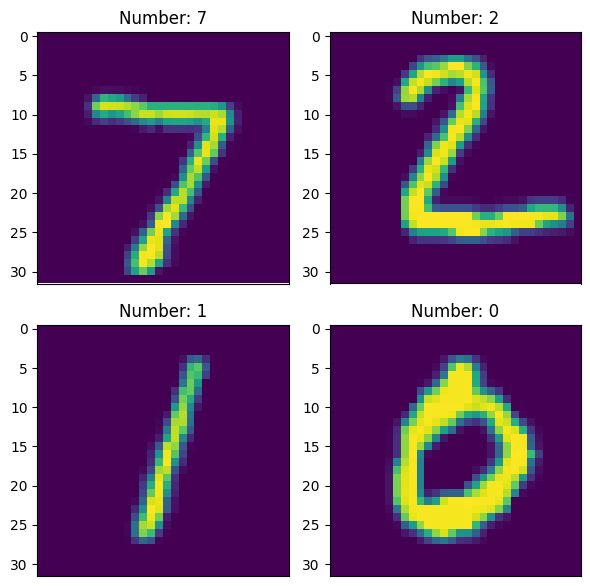

In [ ]:
images, labels = next(iter(test_loader))

plt.figure(figsize=(6, 6))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    img = images[i][0].numpy()
    img = img * 0.3081 + 0.1307 # 反归一化
    plt.imshow(img)
    plt.title(f'Number: {labels[i].item()}')
    plt.xticks([]) # 隐藏 x 轴刻度
plt.tight_layout()
plt.show()

In [ ]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

In [ ]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

    avg_loss = total_loss / total_count
    acc = total_correct / total_count
    return avg_loss, acc


def train(data_dir='MNIST_Data', lr=0.01, momentum=0.9, num_epochs=3, batch_size=32):
    train_loader = create_dataloader(data_dir=data_dir, training=True, batch_size=batch_size)
    test_loader = create_dataloader(data_dir=data_dir, training=False, batch_size=batch_size)

    model = LeNet5().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

        train_loss = running_loss / total_samples
        eval_loss, eval_acc = evaluate(model, test_loader, criterion, device)
        print(f'epoch: {epoch + 1}, train_loss: {train_loss:.6f}, eval_loss: {eval_loss:.6f}, eval_acc: {eval_acc:.6f}')

    print('Metrics:', {'loss': round(eval_loss, 6), 'acc': round(eval_acc, 6)})


train('MNIST_Data')

epoch: 1, train_loss: 0.180388, eval_loss: 0.073617, eval_acc: 0.975761
epoch: 2, train_loss: 0.065681, eval_loss: 0.057263, eval_acc: 0.981971
epoch: 3, train_loss: 0.051254, eval_loss: 0.053076, eval_acc: 0.982973
Metrics: {'loss': 0.053076, 'acc': 0.982973}
